# Qubit Dynamics Under Hamiltonians 
### Time Evolution, Expectation Values, and Larmor Precession

In this notebook, we study the dynamics of a single qubit evolving under a Hamiltonian proportional to the Pauli matrices.  
This is the simplest non‑trivial example of qubit time evolution, and it plays a central role in quantum information and spin physics.

A Hamiltonian of the form  


$$
H = \frac{\hbar\omega}{2}\sigma_z
$$

  
generates a rotation of the Bloch vector around the **z‑axis** with angular frequency $\omega$.  
This corresponds physically to **Larmor precession**, the fundamental motion of a spin‑½ particle in a static magnetic field.

We will:

- define the initial state and Pauli matrices  
- compute the exact time evolution analytically (using the diagonal structure of $\sigma_z$)  
- evaluate the expectation value $\braket{\sigma_x}$ (t)  
- verify probability conservation  
- plot the resulting oscillations  

This notebook is the computational counterpart of the theoretical results derived in Chapter 09.


In [1]:
import numpy as np

# Define the standard basis vectors
ket_0 = np.array([[1],
                  [0]], dtype=complex)
ket_1 = np.array([[0],
                  [1]], dtype=complex)
psi_0 = (1/np.sqrt(2))*np.array([[1],
                                 [1]], dtype=complex)
# Define the Pauli matrices

sigma_x=np.array([[0 , 1], 
                  [1, 0]], dtype=complex)
sigma_y=np.array([[0 , 0-1.j], 
                   [0+1.j, 0]], dtype=complex)
sigma_z=np.array([[1 , 0], 
                  [0, -1]], dtype=complex)

# Define an Hamiltonian proportional to sigma_z (fixing h=1)

omega=1
H=(omega*0.5)*sigma_z

# Define the Unitary transformation
t=np.linspace(0,10,500)

#Hamiltonian is proprtional to sigma_z, so it's diagonal which means that exponential of the matrice equal matrice of exponentials 
# defining exponential of eigenvalues

E1=omega * 0.5
E2=omega * -0.5

#Create the composants of U(t) matrice for each value of t
# So Numpy will broadcast the calculus over t table

u11 = np.exp(-1.j * E1 * t)
u22 = np.exp(-1.j * E2 * t)

# It's not easy to stock 500 matrice 2x2 in an array then do kets multiplication
# the simplest fo psi evolution is:

psi_t = np.array([u11 * psi_0[0,0], 
                  u22 * psi_0[1,0]]) 

# psi_t will have a (2,500) form: each colomn is the state at t.

# psi_t.conj() give the bra (conjugat complex)
# We calculate for all t at once:

exp_x = np.sum(psi_t.conj() * (sigma_x @ psi_t), axis=0).real

# Total probability : |psi_1|^2 + |psi_2|^2

prob_totale = np.abs(psi_t[0])**2 + np.abs(psi_t[1])**2

# prob_totale should be an array of 500 of value 1.0

print(prob_totale[:5]) # Show 5 first points

[1. 1. 1. 1. 1.]


## Time Evolution Under a $\sigma_z$ Hamiltonian

We begin by defining the computational basis states $\ket0$ and $\ket1$, the Pauli matrices, and the initial state:


$$\ket{\psi(0)} = \frac{1}{\sqrt{2}}($\ket0$ + $\ket1$),$$


which corresponds to a Bloch vector initially aligned along the **x‑axis**.

We choose a Hamiltonian proportional to $\sigma_z$:


$$H = \frac{\omega}{2}\sigma_z.$$


Since σ_z is diagonal, its exponential is extremely simple:


$$e^{-iHt} = 
\begin{pmatrix}
e^{-i\omega t/2} & 0 \\
0 & e^{+i\omega t/2}
\end{pmatrix}.$$



This means that the two components of the spinor acquire **opposite phases**.  
There is **no population transfer** between $\ket0$ and $\ket1$ — only a **relative phase evolution**, which corresponds to a rotation around the z‑axis on the Bloch sphere.

We compute the evolved state $\psi(t)$ for 500 time points, and then evaluate:

- the expectation value  
  


  $$\langle\sigma_x\rangle(t) = \psi(t)^\dagger \sigma_x \psi(t)$$


- the total probability  
  

  $$|\psi_0(t)|^2 + |\psi_1(t)|^2 = 1$$



The probability check confirms that the evolution is unitary.


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_12132\300287003.py:10: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Lamor precession : $\sigma_x$ mean value's evolution", fontsize=14)


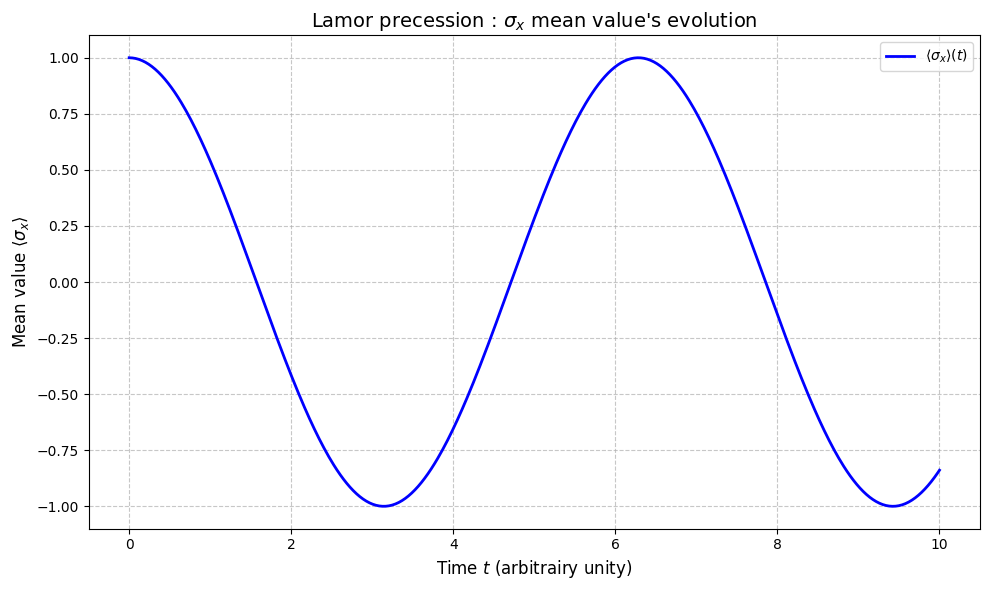

In [2]:
import matplotlib.pyplot as plt

# Configuration
plt.figure(figsize=(10, 6))

# plot mean value of sigma_x in function of time
plt.plot(t, exp_x, label=r'$\langle \sigma_x \rangle(t)$', color='blue', linewidth=2)

# Adds cosmetic details 
plt.title("Lamor precession : $\sigma_x$ mean value's evolution", fontsize=14)
plt.xlabel('Time $t$ (arbitrairy unity)', fontsize=12)
plt.ylabel(r'Mean value $\langle \sigma_x \rangle$', fontsize=12)

# We fix the limits of the Y axis, because a mean value of a spin is between -1 & 1
plt.ylim(-1.1, 1.1)

# Adds grid to make reading easier
plt.grid(True, linestyle='--', alpha=0.7)

# Adds the legend
plt.legend(loc='upper right')

# Graphic display
plt.tight_layout()
plt.savefig('larmor_precession.png')
plt.show()

## Plotting the Expectation Value ⟨σ_x⟩(t)

The expectation value ⟨σ_x⟩(t) oscillates in time because the initial state is an eigenstate of $\sigma_x$, while the Hamiltonian generates a rotation around the z‑axis.

From the analytical solution:



$$\ket{\psi(t)} = 
\frac{1}{\sqrt{2}}
\begin{pmatrix}
e^{-i\omega t/2} \\
e^{+i\omega t/2}
\end{pmatrix},$$


we obtain:


$$\langle\sigma_x\rangle(t) = \cos(\omega t).$$



This is exactly what the plot shows: a **cosine oscillation** of amplitude 1.  
Physically, this is **Larmor precession**: the Bloch vector rotates in the equatorial plane, and its projection on the x‑axis oscillates.

The plot includes:

- axis labels  
- a fixed y‑range (since ⟨σ_x⟩ ∈ [−1, 1])  
- a grid for readability  
- a legend and a title  

The resulting figure clearly illustrates the periodic nature of the qubit dynamics under a σ_z Hamiltonian.
